# NYC HVFHV — Exploratory Data Analysis

Profiles the NYC High Volume For-Hire Vehicle (HVFHV) trip dataset (Jan–May 2026,
Uber + Lyft) to assess data quality before any downstream analysis or modeling.

**Data source:** TLC HVFHV monthly parquet files, `../data/raw/fhvhv_tripdata_2026-*.parquet`

In [1]:
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect()

con.execute("""
CREATE OR REPLACE VIEW fhvhv AS
SELECT *
FROM read_parquet('../data/raw/fhvhv_tripdata_2026-*.parquet');
""")

In [2]:
con.sql("""
SELECT
    *
FROM fhvhv
LIMIT 10;
""").df()

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
0,HV0003,B03404,B03404,2026-01-01 00:50:37,2026-01-01 00:52:31,2026-01-01 00:54:30,2026-01-01 01:13:23,262,79,4.300,...,2.75,0.0,0.00,21.10,N,N,N,N,N,1.5
1,HV0003,B03404,B03404,2026-01-01 00:09:12,2026-01-01 00:12:17,2026-01-01 00:12:39,2026-01-01 00:22:42,195,52,1.890,...,0.00,0.0,0.00,9.10,N,N,N,N,N,0.0
2,HV0003,B03404,B03404,2026-01-01 00:16:16,2026-01-01 00:29:33,2026-01-01 00:31:34,2026-01-01 00:55:21,25,181,1.840,...,0.00,0.0,2.67,21.94,N,N,N,N,N,0.0
3,HV0005,B03406,NaN,2026-01-01 00:08:19,2026-01-01 00:09:08,2026-01-01 00:09:37,2026-01-01 00:22:12,141,226,3.307,...,2.75,0.0,0.00,13.42,N,N,N,N,Y,1.5
4,HV0005,B03406,NaN,2026-01-01 00:21:16,2026-01-01 00:26:30,2026-01-01 00:26:40,2026-01-01 00:39:06,226,226,2.060,...,0.00,0.0,2.98,11.39,N,N,N,N,Y,0.0
5,HV0005,B03406,NaN,2026-01-01 00:39:02,2026-01-01 00:45:17,2026-01-01 00:45:34,2026-01-01 00:52:20,260,82,1.420,...,0.00,0.0,0.00,10.66,N,N,N,N,Y,0.0
6,HV0005,B03406,NaN,2026-01-01 00:36:04,2026-01-01 00:55:27,2026-01-01 00:56:27,2026-01-01 01:07:09,82,95,1.631,...,0.00,0.0,0.00,15.58,N,N,N,N,Y,0.0
7,HV0005,B03406,NaN,2026-01-01 00:20:23,2026-01-01 00:24:27,2026-01-01 00:25:27,2026-01-01 01:04:37,144,246,3.883,...,2.75,0.0,0.00,30.69,N,N,N,N,N,1.5
8,HV0003,B03404,B03404,2026-01-01 00:29:54,2026-01-01 00:36:04,2026-01-01 00:36:32,2026-01-01 01:02:28,162,113,2.840,...,2.75,0.0,0.00,20.90,N,N,N,N,N,1.5
9,HV0005,B03406,NaN,2026-01-01 00:45:36,2026-01-01 00:53:32,2026-01-01 00:54:32,2026-01-01 01:43:28,148,265,24.381,...,0.00,0.0,0.00,87.54,N,N,N,N,N,1.5


In [3]:
con.sql("""
DESCRIBE fhvhv
""").df()

,column_name,column_type,null,key,default,extra
0,hvfhs_license_num,VARCHAR,YES,None,None,None
1,dispatching_base_num,VARCHAR,YES,None,None,None
2,originating_base_num,VARCHAR,YES,None,None,None
3,request_datetime,TIMESTAMP,YES,None,None,None
4,on_scene_datetime,TIMESTAMP,YES,None,None,None
5,pickup_datetime,TIMESTAMP,YES,None,None,None
6,dropoff_datetime,TIMESTAMP,YES,None,None,None
7,PULocationID,INTEGER,YES,None,None,None
8,DOLocationID,INTEGER,YES,None,None,None
9,trip_miles,DOUBLE,YES,None,None,None


### Dataset Schema

Key observations:
- Four timestamp fields (`request_datetime`, `on_scene_datetime`, `pickup_datetime`, `dropoff_datetime`) capture the trip lifecycle and support time-based analysis.
- Geographic information is represented by pickup and drop-off IDs (`PULocationID`, `DOLocationID`).
- Fare and fee components are stored separately (`base_passenger_fare`, `tolls`, `bcf`, `sales_tax`, `congestion_surcharge`, `airport_fee`, `cbd_congestion_fee`, `tips`).
- `driver_pay` is available, enabling comparison between passenger payments and driver compensation.
- `trip_miles` and `trip_time` support derived metrics such as fare per mile, fare per minute, and average speed.
- Operational flag fields are stored as `Y`/`N` strings rather than boolean values.
- Some records have `on_scene_datetime` earlier than `request_datetime`; this will be investigated further if these timestamps are used in later analyses.

In [4]:
con.sql("""
SELECT
    COUNT(*) AS total_rows
FROM fhvhv;
""").df()

,total_rows
0,105996114


In [5]:
con.sql("""
SELECT
    *,
    COUNT(*) AS duplicate_count
FROM fhvhv
GROUP BY ALL
HAVING COUNT(*) > 1;
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee,duplicate_count
0,HV0003,B03404,B03404,2026-03-20 07:06:59,2026-03-20 07:07:38,2026-03-20 07:07:49,2026-03-20 07:20:33,4,162,2.43,...,0.0,0.0,8.66,Y,Y,N,N,N,1.5,2


One exact duplicate trip record was identified using all columns as the comparison key. Given the extremely small proportion of duplicate records relative to the full dataset, this discrepancy will be excluded from further analysis.

In [6]:
con.sql("""
SUMMARIZE fhvhv;
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,column_name,column_type,min,max,approx_unique,avg,std,q25,q50,q75,count,null_percentage
0,hvfhs_license_num,VARCHAR,HV0003,HV0005,1,NaN,NaN,NaN,NaN,NaN,105996114,0.0
1,dispatching_base_num,VARCHAR,B02878,B03406,3,NaN,NaN,NaN,NaN,NaN,105996114,0.0
2,originating_base_num,VARCHAR,B00887,B03406,7,NaN,NaN,NaN,NaN,NaN,105996114,28.1
3,request_datetime,TIMESTAMP,2025-12-31 23:00:00,2026-06-01 00:31:00,17231468,2026-03-18 04:42:02.935722,NaN,2026-02-08 13:45:00.270128,2026-03-17 19:56:30.151206,2026-04-25 03:00:21.22597,105996114,0.0
4,on_scene_datetime,TIMESTAMP,2025-12-31 23:07:56,2026-06-01 00:04:35,16453614,2026-03-18 04:46:13.20063,NaN,2026-02-08 19:26:36.798971,2026-03-17 23:40:06.888166,2026-04-25 03:49:54.910962,105996114,0.0
5,pickup_datetime,TIMESTAMP,2026-01-01 00:00:00,2026-05-31 23:59:59,17231468,2026-03-18 04:47:12.796025,NaN,2026-02-08 11:49:53.300952,2026-03-17 17:53:06.82041,2026-04-25 00:34:13.484774,105996114,0.0
6,dropoff_datetime,TIMESTAMP,2026-01-01 00:00:56,2026-06-01 03:09:05,16585738,2026-03-18 05:06:41.669359,NaN,2026-02-08 17:04:25.922162,2026-03-17 21:09:37.240192,2026-04-25 07:48:38.924842,105996114,0.0
7,PULocationID,INTEGER,1,265,298,137.89065570837815,75.05238196998165,74,139,208,105996114,0.0
8,DOLocationID,INTEGER,1,265,298,141.53280179686587,78.28305163792923,75,140,216,105996114,0.0
9,trip_miles,DOUBLE,0.0,1644.54,65751,4.7870376861552515,5.709170277788009,1.4555349017660733,2.792651107476849,5.942036759195238,105996114,0.0


### Quality Checks

Initial quality checks were performed using DuckDB's `SUMMARIZE` function.

Key observations:
- `hvfhs_license_num` reports a single approximate unique value, but the minimum and maximum values differ. This requires further investigation.
- `dispatching_base_num` contains three unique values, suggesting a limited number of dispatch bases are represented in the dataset.
- `originating_base_num` contains approximately 28.1% missing values.
- Timestamp fields (`request_datetime`, `on_scene_datetime`, `pickup_datetime`, and `dropoff_datetime`) require validation to ensure logical ordering (e.g., request time occurs before pickup time and dropoff time).
- The dataset spans January–May 2026 based on pickup and dropoff timestamps, while `request_datetime` includes records from late December 2025 and early June 2026. This likely reflects trips requested near month boundaries that crossed into adjacent dates.
- `PULocationID` and `DOLocationID` range from 1 to 265, but approximately 298 distinct values are reported. This discrepancy requires further investigation.
- `trip_miles` and `trip_time` contain zero values and exhibit extreme outliers. Zero-valued trips may require special handling when computing derived metrics (e.g., fare per mile or average speed).
- `base_passenger_fare` and `driver_pay` contain negative values, which require further investigation before performing fare or revenue analysis.
- Fare-related metrics should be validated
- `airport_fee` is zero for most trips, indicating that airport trips represent a relatively small share of the dataset.
- `tips` are zero for most trips, suggesting that many trips did not include a recorded tip.
- Binary indicator columns (`shared_request_flag`, `shared_match_flag`, `access_a_ride_flag`, `wav_request_flag`, and `wav_match_flag`) should be evaluated for class imbalance to understand their distribution and potential usefulness for analysis.

## Provider and Dispatch Base Concentration Analysis

In [7]:
# Inspect the concentration of hvfhs_license_num
con.sql("""
SELECT
    DISTINCT hvfhs_license_num,
    COUNT(*) AS hvfhs_license_num_count
FROM fhvhv
GROUP BY hvfhs_license_num;
""").df()

,hvfhs_license_num,hvfhs_license_num_count
0,HV0003,76102441
1,HV0005,29893673


Only Uber (HV0003) and Lyft (HV0005) are represented in the dataset, highlighting the market's concentration around these two providers.

In [8]:
# Inspect the concentration of dispatching_base_num
con.sql("""
SELECT
    DISTINCT dispatching_base_num,
    COUNT(*) AS dispatching_base_num_count
FROM fhvhv
GROUP BY dispatching_base_num;
""").df()

,dispatching_base_num,dispatching_base_num_count
0,B03406,29893673
1,B03404,76102412
2,B02878,29


`dispatching_base_num` contains three unique bases. Two bases (B03404 and B03406) account for virtually all trips, while B02878 appears only 29 times. This indicates that dispatching activity in the January–May 2026 dataset is highly concentrated among two primary bases.

## Originating Base Analysis

In [9]:
# Inspect missing originating_base_num
con.sql("""
SELECT
    COUNT(*) AS total_trips,
    SUM(CASE WHEN originating_base_num IS NULL THEN 1 ELSE 0 END) AS missing_originating_base_num,
    (SUM(CASE WHEN originating_base_num IS NULL THEN 1 ELSE 0 END) * 1.0 / COUNT(*)) * 100 AS missing_pct
FROM fhvhv;
""").df()

,total_trips,missing_originating_base_num,missing_pct
0,105996114,29786073.0,28.101099


For missing `originating_base_num`, we can investigate the distribution of other columns to see if there are any patterns or correlations that might explain the missing values.

#### Q1: Is missing `originating_base_num` more common with Uber or Lyft trips?

In [10]:
con.sql("""
SELECT
    hvfhs_license_num,
    SUM(CASE WHEN originating_base_num IS NULL THEN 1 ELSE 0 END) AS missing_originating_base_num
FROM fhvhv
GROUP BY hvfhs_license_num;
""").df()

,hvfhs_license_num,missing_originating_base_num
0,HV0005,29786073.0
1,HV0003,0.0


#### Q2: Are missing `originating_base_num` trips randomly distributed for Lyft?

In [11]:
# Using the percentage of missing trips to account for daily fluctuations in Lyft trip volume
# Is one month unusually high or low?
con.sql("""
SELECT
    EXTRACT(MONTH FROM pickup_datetime) AS cal_month,
    COUNT(*) AS total_trips,
    SUM(CASE WHEN originating_base_num IS NULL THEN 1 ELSE 0 END) AS missing_originating_base_num,
    (SUM(CASE WHEN originating_base_num IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*)) AS missing_percentage
FROM fhvhv
WHERE hvfhs_license_num = 'HV0005'
GROUP BY cal_month
ORDER BY cal_month;
""").df()

,cal_month,total_trips,missing_originating_base_num,missing_percentage
0,1,5694742,5676843.0,99.685693
1,2,5708725,5691209.0,99.693171
2,3,6102183,6079600.0,99.629919
3,4,5617095,5594175.0,99.591960
4,5,6770928,6744246.0,99.605933


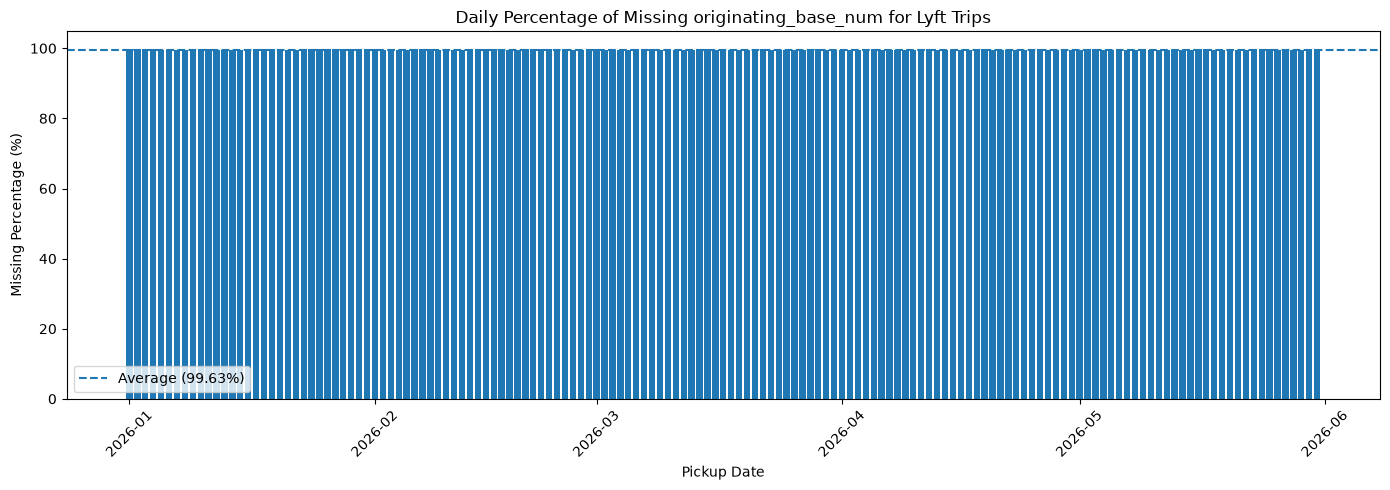

In [12]:
# Are there specific dates with unusually high or low missing originating_base_num trips?
base_df = con.sql("""
SELECT
    DATE(pickup_datetime) AS cal_date,
    COUNT(*) AS total_trips,
    SUM(CASE WHEN originating_base_num IS NULL THEN 1 ELSE 0 END) AS missing_originating_base_num,
    (SUM(CASE WHEN originating_base_num IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*)) AS missing_percentage
FROM fhvhv
WHERE hvfhs_license_num = 'HV0005'
GROUP BY cal_date
ORDER BY cal_date;
""").df()

avg_missing = base_df["missing_percentage"].mean()

plt.figure(figsize=(14, 5))

plt.bar(base_df["cal_date"], base_df["missing_percentage"], width=0.8)
plt.axhline(avg_missing, linestyle="--", label=f"Average ({avg_missing:.2f}%)")

plt.title("Daily Percentage of Missing originating_base_num for Lyft Trips")
plt.xlabel("Pickup Date")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

### Findings
- The percentage of missing `originating_base_num` values remains consistently around ~99.6% across all five months.
- No individual month exhibits an unusually high or low missing rate relative to the overall average.
- The results suggest that the missingness is more likely due to Lyft's reporting practices than to changes over time.

## Timestamp Analysis

In [13]:
# Business expectation:
# A trip request should occur before the driver arrives on scene.
# Investigate records where on_scene_datetime occurs before request_datetime.
con.sql("""
SELECT
    COUNT(*) AS count,
    MIN(request_datetime - on_scene_datetime) AS min_gap,
    MAX(request_datetime - on_scene_datetime) AS max_gap,
    AVG(request_datetime - on_scene_datetime) AS avg_gap
FROM fhvhv
WHERE on_scene_datetime < request_datetime;
""").df()

,count,min_gap,max_gap,avg_gap
0,1906150,0 days 00:00:01,1 days 00:16:29,0 days 00:10:00.095214


In [14]:
# Business expectation:
# A trip pickup should occur after the driver arrives on scene.
# Investigate records where on_scene_datetime occurs after pickup_datetime.
con.sql("""
SELECT
    COUNT(*) AS count,
    MIN(on_scene_datetime - pickup_datetime) AS min_gap,
    MAX(on_scene_datetime - pickup_datetime) AS max_gap,
    AVG(on_scene_datetime - pickup_datetime) AS avg_gap
FROM fhvhv
WHERE on_scene_datetime > pickup_datetime;
""").df()

,count,min_gap,max_gap,avg_gap
0,3221,0 days 00:00:01,0 days 03:53:12,0 days 00:09:07.364360


In [15]:
# Business expectation:
# A trip dropoff should occur after the driver picks up the passenger.
# Investigate records where dropoff_datetime occurs before pickup_datetime.
con.sql("""
SELECT
    COUNT(*) AS count,
    MIN(dropoff_datetime - pickup_datetime) AS min_gap,
    MAX(dropoff_datetime - pickup_datetime) AS max_gap,
    AVG(dropoff_datetime - pickup_datetime) AS avg_gap
FROM fhvhv
WHERE dropoff_datetime < pickup_datetime;
""").df()

,count,min_gap,max_gap,avg_gap
0,0,NaT,NaT,NaT


#### Q1: Are invalid timestamps more common with Uber or Lyft trips?

In [16]:

con.sql("""
SELECT
    hvfhs_license_num as provider_id,
    COUNT(*) AS total_trips,
    SUM(CASE WHEN (
        request_datetime > on_scene_datetime
        OR on_scene_datetime > pickup_datetime
        OR pickup_datetime > dropoff_datetime
    ) THEN 1 ELSE 0 END) AS invalid_timestamp_count,
    SUM(CASE WHEN (
        request_datetime > on_scene_datetime
        OR on_scene_datetime > pickup_datetime
        OR pickup_datetime > dropoff_datetime
    ) THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS invalid_timestamp_pct
FROM fhvhv
GROUP BY hvfhs_license_num;
""").df()

,provider_id,total_trips,invalid_timestamp_count,invalid_timestamp_pct
0,HV0005,29893673,513740.0,1.718558
1,HV0003,76102441,1394710.0,1.832674


### Findings
- Approximately 1.8% of trips contain timestamp ordering inconsistencies where `on_scene_datetime` occurs before `request_datetime`. The average discrepancy is around 10 minutes, with the largest exceeding one day. Since these records represent a small portion of the dataset, the issue is documented and will only be investigated further if request or driver arrival timestamps are used.
- Approximately 3,200 trips contain cases where `on_scene_datetime` occurs after `pickup_datetime`, which indicates potential data issues.
- Timestamp inconsistencies appear consistent across providers. The invalid timestamp percentages are similar between Uber and Lyft, suggesting the issue is not provider-specific.

## Pickup and Drop-off Location Analysis

In [17]:
# Investigate PULocationID and DOLocationID discrepancies
con.sql("""
SELECT
    DISTINCT PULocationID, DOLocationID
FROM fhvhv
WHERE PULocationID < 1 OR PULocationID > 265
    OR DOLocationID < 1 OR DOLocationID > 265
ORDER BY PULocationID, DOLocationID;
""").df()

,PULocationID,DOLocationID


In [18]:
con.sql("""
SELECT
    COUNT(DISTINCT PULocationID) AS distinct_pu_location_count,
    COUNT(DISTINCT DOLocationID) AS distinct_do_location_count
FROM fhvhv;
""").df()

,distinct_pu_location_count,distinct_do_location_count
0,262,264


### Findings
- `PULocationID` and `DOLocationID` have values within the expected range of 1–265.
- Initial profiling reported approximately 298 unique values, but a direct DISTINCT count found 262 unique pickup locations and 264 unique dropoff locations.
- There are no invalid location identifiers in the dataset.

## Trip Distance and Duration Analysis

In [19]:
# Inspect distribution of zero or negative trip distances
con.sql("""
SELECT
    COUNT(*) AS total_trips,
    SUM(CASE WHEN trip_miles <= 0 THEN 1 ELSE 0 END) AS zero_or_negative_distance_count,
    (SUM(CASE WHEN trip_miles <= 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*)) AS zero_or_negative_distance_pct
FROM fhvhv;
""").df()

,total_trips,zero_or_negative_distance_count,zero_or_negative_distance_pct
0,105996114,11501.0,0.01085


In [20]:
# Inspect distribution of zero or negative trip durations
con.sql("""
SELECT
    COUNT(*) AS total_trips,
    SUM(CASE WHEN (dropoff_datetime - pickup_datetime) <= INTERVAL '0 seconds' THEN 1
            ELSE 0 END) AS zero_or_negative_duration_count,
    (SUM(CASE WHEN (dropoff_datetime - pickup_datetime) <= INTERVAL '0 seconds' THEN 1
            ELSE 0 END) * 100.0 / COUNT(*)) AS zero_or_negative_duration_pct
FROM fhvhv;
""").df()

,total_trips,zero_or_negative_duration_count,zero_or_negative_duration_pct
0,105996114,2.0,0.000002


In [21]:
# Inspect outliers in trip distances and durations
valid_trip_df = con.sql("""
SELECT
    trip_miles,
    (dropoff_datetime - pickup_datetime) AS trip_duration
FROM fhvhv
WHERE trip_miles > 0
    AND (dropoff_datetime - pickup_datetime) > INTERVAL '0 seconds';
""").df()

# Function to find outliers using the IQR method
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

dist_outliers = find_outliers(valid_trip_df, 'trip_miles')
duration_outliers = find_outliers(valid_trip_df, 'trip_duration')

print(f"Number of outliers in trip distances: {len(dist_outliers)}")
print(f"Number of outliers in trip durations: {len(duration_outliers)}")

Number of outliers in trip distances: 8226805
Number of outliers in trip durations: 4700067


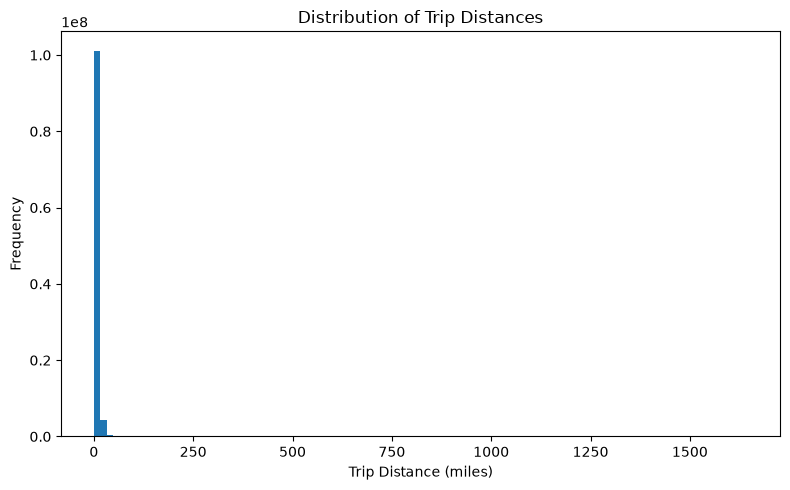

In [22]:
# Histogram for trip distances
plt.figure(figsize=(8, 5))
plt.hist(valid_trip_df["trip_miles"], bins=100)
plt.title("Distribution of Trip Distances")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

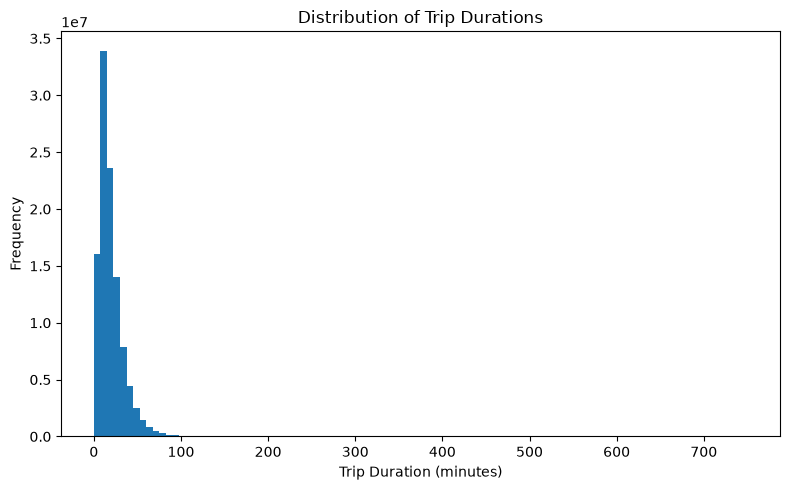

In [23]:
# Histogram for trip duration
plt.figure(figsize=(8, 5))
plt.hist(valid_trip_df["trip_duration"].dt.total_seconds() / 60, bins=100)
plt.title("Distribution of Trip Durations")
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Findings
- `trip_miles` and `trip_time` contain a large number of IQR-based outliers (8.2M trips for distance, 4.7M trips for duration).
- Zero or negative values represent a small portion of the dataset and will be excluded for computation.
- These outliers are expected due to the right-skewed nature of ride data, where most trips are short but a smaller number of trips are significantly longer.
- These records will be retained for analysis because they may represent legitimate ride patterns rather than data quality issues.

## Fare and Cost Analysis

In [24]:
con.sql("""
SELECT
    COUNT(*) AS total_trips,
    SUM(CASE WHEN base_passenger_fare <= 0 THEN 1 ELSE 0 END) AS invalid_base_passenger_fare_count,
    SUM(CASE WHEN driver_pay <= 0 THEN 1 ELSE 0 END) AS invalid_driver_pay_count,
    (SUM(CASE WHEN base_passenger_fare <= 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*)) AS invalid_base_passenger_fare_pct,
    (SUM(CASE WHEN driver_pay <= 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*)) AS invalid_driver_pay_pct
FROM fhvhv;
""").df()

,total_trips,invalid_base_passenger_fare_count,invalid_driver_pay_count,invalid_base_passenger_fare_pct,invalid_driver_pay_pct
0,105996114,151312.0,60970.0,0.142752,0.057521


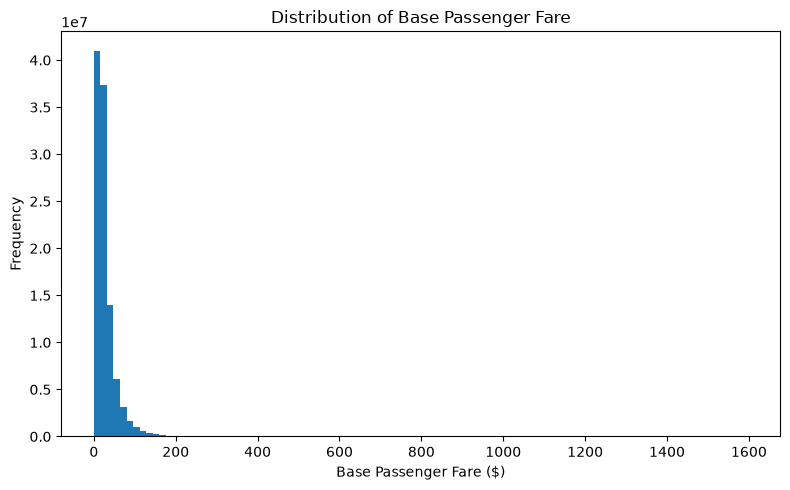

In [25]:
fare_df = con.sql("""
SELECT
    base_passenger_fare,
    driver_pay
FROM fhvhv
WHERE base_passenger_fare > 0 AND driver_pay > 0;
""").df()

# Histogram for base passenger fare
plt.figure(figsize=(8, 5))

plt.hist(fare_df["base_passenger_fare"], bins=100)

plt.title("Distribution of Base Passenger Fare")
plt.xlabel("Base Passenger Fare ($)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

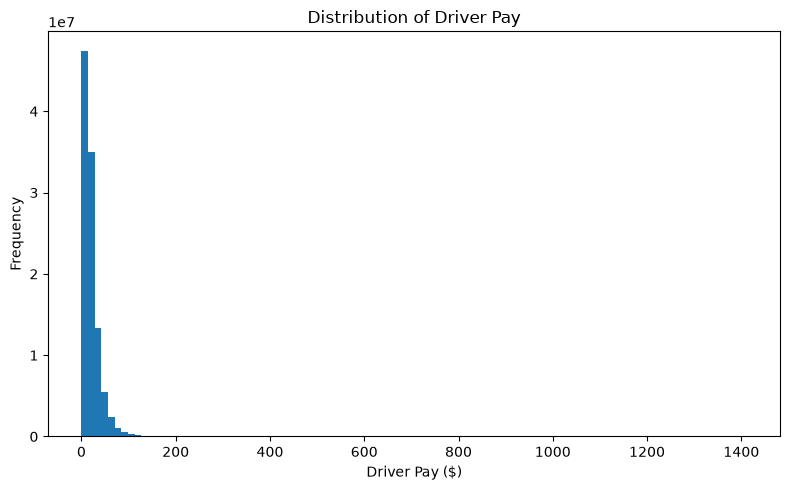

In [26]:
# Histogram for driver pay
plt.figure(figsize=(8, 5))
plt.hist(fare_df["driver_pay"], bins=100)
plt.title("Distribution of Driver Pay")
plt.xlabel("Driver Pay ($)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Findings
- The distributions of `base_passenger_fare` and `driver_pay` are right-skewed, with most trips having relatively low values and a smaller number of high-value trips.
- 151,312 trips (0.143%) have non-positive base_passenger_fare values.
- 60,970 trips (0.058%) have non-positive driver_pay values.
- Since these records represent a very small proportion of the dataset, they will be excluded from analyses.

## Binary Flag Analysis

In [27]:
con.sql("""
SELECT
    SUM(CASE WHEN shared_request_flag = 'Y' THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS shared_request_pct,
    SUM(CASE WHEN shared_match_flag = 'Y' THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS shared_match_pct,
    SUM(CASE WHEN access_a_ride_flag = 'Y' THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS access_a_ride_pct,
    SUM(CASE WHEN wav_request_flag = 'Y' THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS wav_request_pct,
    SUM(CASE WHEN wav_match_flag = 'Y' THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS wav_match_pct
FROM fhvhv;
""").df()

,shared_request_pct,shared_match_pct,access_a_ride_pct,wav_request_pct,wav_match_pct
0,1.831527,1.055667,0.094988,0.279959,9.43093


### Findings
| Flag                          | Observation                                                                                                                                                                                                                                                    |
| ----------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `shared_request_flag` (1.83%) | About 1.83% of trips were requested as shared rides.                                                                                                                                                                                                               |
| `shared_match_flag` (1.06%)   | About 1.06% of trips actually became shared rides.                                                                                                                                                                                                                 |
| `access_a_ride_flag` (0.095%) | Access-A-Ride trips are very rare in the dataset.                                                                                                                                                                                                                 |
| `wav_request_flag` (0.28%)    | Few passengers requested a wheelchair-accessible vehicle.                                                                                                                                                                                                         |
| `wav_match_flag` (9.43%)      | Many more trips occurred in a WAV than were explicitly requested as WAVs. This is expected because of FHV Accessibility Rules.

In [28]:
# Close the DuckDB connection
con.close()